# RQ3: Same options, same use?

*When the two cohorts reach for the same option, do they use it in the same way?*

A single three-panel figure (`rq4_style.pdf`), built like the RQ1 figure, carries the whole answer:

- **(a) Relative popularity.** For options both cohorts share, relative popularity is rank-correlated (each shared option is placed at its human use share against its model use share).
- **(b) Spelling form.** The dominant spelling agrees too: per dataset both cohorts overwhelmingly pick the same form (short `-x` vs long `--word`).
- **(c) Configuration depth.** How many options a cohort supplies in a single call — the bar darkens as the call goes deeper (0 → 4+ options). This per-invocation depth is corpus-size-independent, unlike a raw count of distinct option combinations.

The thesis across all three: where the cohorts share an option they use it alike; they part company mainly in how deeply they configure each call.

Output: `results/analysis/figures/rq4_style.pdf`


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches
from scipy.stats import spearmanr

# Locate the replication-package results directory (walk up from the notebook).
BASE = Path.cwd()
while not (BASE / 'results' / 'analysis').exists() and BASE != BASE.parent:
    BASE = BASE.parent
AN  = BASE / 'results' / 'analysis'
FIG = AN / 'figures'; FIG.mkdir(exist_ok=True)
def load(name): return pd.read_csv(AN / name)

# Refined, minimal house style (identical to the RQ1–RQ3 figures).
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 12.5,
    'axes.titlesize': 14, 'axes.titleweight': 'bold', 'axes.titlepad': 12,
    'axes.labelsize': 12, 'axes.labelcolor': '#222222',
    'axes.edgecolor': '#9aa0a6', 'axes.linewidth': 0.9,
    'xtick.color': '#3c4043', 'ytick.color': '#3c4043',
    'xtick.labelsize': 11.5, 'ytick.labelsize': 11.5,
    'text.color': '#202124',
    'axes.spines.top': False, 'axes.spines.right': False,
    'figure.dpi': 130, 'savefig.bbox': 'tight', 'pdf.fonttype': 42,
})

# Okabe-Ito palette (colourblind-safe, consistent with the paper).
C    = {'human': '#0072B2', 'llm': '#D55E00', 'kernel': '#009E73'}
DS   = ['gnu', 'git', 'ci']
DSS  = {'gnu': 'GNU', 'git': 'Git', 'ci': 'CI'}
LAB  = {'kernel': 'expert', 'human': 'human', 'llm': 'model'}
print('results dir:', AN.relative_to(BASE))


results dir: results/analysis


In [2]:
# data for RQ3
pop  = load('a2_option_popularity.csv')   # per shared option: human_pct, llm_pct
form = load('a4_form_preference.csv')      # short vs long spelling share per cohort

# Spearman rank correlation of relative popularity, per dataset shared core.
rho = {}
for d in DS:
    g = pop[(pop.dataset == d) & (pop.status == 'shared')]
    rho[d] = (spearmanr(g['human_pct'], g['llm_pct'])[0], len(g))

# options combined per invocation (the range of combination depth)
# Per-invocation option counts, recovered from the raw invocation tables.
INV = {
    ('gnu', 'human'):  (BASE / 'results/gnu/human_invocations.csv',     'option_count'),
    ('gnu', 'llm'):    (BASE / 'results/gnu/llm_invocations.csv',        'option_count'),
    ('gnu', 'kernel'): (BASE / 'results/gnu/coreutils_invocations.csv',  'option_count'),
    ('ci',  'human'):  (BASE / 'results/ci/human_ci_invocations.csv',    'option_count'),
    ('ci',  'llm'):    (BASE / 'results/ci/llm_ci_invocations.csv',      'option_count'),
}
BUCKETS = ['0', '1', '2', '3', '4+']
def bucketise(counts):
    c = pd.Series(counts).astype(int); n = len(c)
    raw = [(c == 0).sum(), (c == 1).sum(), (c == 2).sum(), (c == 3).sum(), (c >= 4).sum()]
    return np.array([100.0 * v / n for v in raw]), c.mean(), int(c.max())

depth = {}   # (dataset, cohort) -> (pct per bucket, mean, max)
for k, (f, col) in INV.items():
    depth[k] = bucketise(pd.read_csv(f)[col])
# Git per-invocation counts live in the results raw table (group, num_options).
gitraw = pd.read_csv(BASE / 'results/git/git_invocations_raw.csv')
for grp in ('human', 'llm'):
    depth[('git', grp)] = bucketise(gitraw.loc[gitraw.group == grp, 'num_options'])

rho, {k: (v[0].round(1).tolist(), round(v[1], 2), v[2]) for k, v in depth.items()}


({'gnu': (np.float64(0.6333442846716064), 88),
  'git': (np.float64(0.6073343450915093), 59),
  'ci': (np.float64(-0.00925925925925926), 7)},
 {('gnu', 'human'): ([66.3, 24.2, 8.4, 0.8, 0.3], np.float64(0.45), 6),
  ('gnu', 'llm'): ([73.4, 22.0, 3.4, 0.7, 0.5], np.float64(0.34), 26),
  ('gnu', 'kernel'): ([76.0, 19.4, 4.0, 0.5, 0.1], np.float64(0.29), 5),
  ('ci', 'human'): ([48.5, 33.2, 8.8, 6.5, 3.1], np.float64(0.83), 6),
  ('ci', 'llm'): ([60.3, 35.5, 3.3, 0.6, 0.3], np.float64(0.45), 4),
  ('git', 'human'): ([0.0, 85.3, 12.1, 2.5, 0.2], np.float64(1.18), 4),
  ('git', 'llm'): ([0.0, 81.1, 17.7, 1.0, 0.2], np.float64(1.2), 4)})

wrote results/analysis/figures/rq4_style.pdf


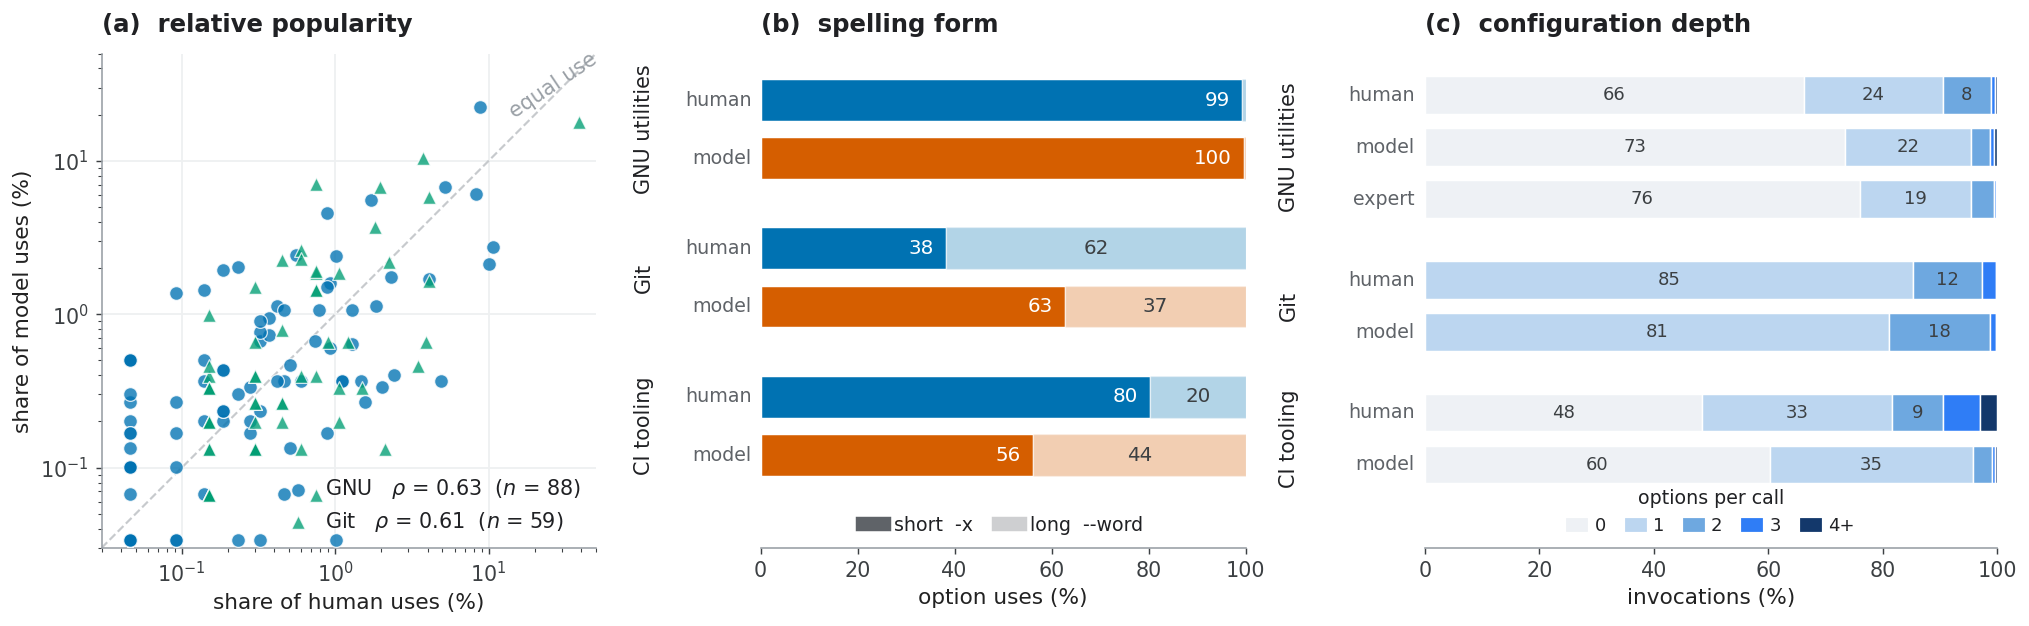

In [3]:
# RQ3: one figure, three panels (styled like the RQ1 figure)
# (a) relative popularity   (b) spelling form   (c) configuration depth.
# Vivid colours, light tracks, on-bar annotations and grouped dataset blocks,
# matching the look of the RQ1 saturation figure.
USED  = '#2f7df6'                       # vivid azure (shared with RQ1)
TRACK = '#eef1f5'                       # soft light track
SHORT = {'gnu': 'GNU', 'git': 'Git', 'ci': 'CI'}
DSL   = {'gnu': 'GNU utilities', 'git': 'Git', 'ci': 'CI tooling'}
DEPTH = ['#eef1f5', '#bcd6f0', '#6ea8e0', '#2f7df6', '#13386b']   # 0,1,2,3,4+  shallow->deep

fig, (axA, axB, axC) = plt.subplots(
    1, 3, figsize=(15.5, 4.7),
    gridspec_kw={'width_ratios': [1.12, 1.0, 1.18]})
fig.set_constrained_layout(True)

# helper: grouped horizontal rows (dataset blocks, cohort sub-rows)
def grouped_layout(order):
    ypos, ylab, rows, centers = [], [], [], {}
    yy = 0.0
    for d in DS:
        start = yy
        for p in order[d]:
            ypos.append(yy); ylab.append(LAB[p]); rows.append((d, p)); yy += 1
        centers[d] = (start + yy - 1) / 2; yy += 0.55
    return np.array(ypos), ylab, rows, centers

# (a) relative popularity
MK = {'gnu': ('o', C['human']), 'git': ('^', C['kernel'])}
axA.plot([0.03, 50], [0.03, 50], '--', color='#c7cacd', lw=1.2, zorder=1)
axA.text(13, 18, 'equal use', rotation=34, color='#9aa0a6', fontsize=11.5, va='bottom')
for d in ('gnu', 'git'):
    g = pop[(pop.dataset == d) & (pop.status == 'shared')]
    mk, col = MK[d]
    axA.scatter(g['human_pct'], g['llm_pct'], s=58, marker=mk, alpha=0.78,
                facecolor=col, edgecolor='white', linewidth=0.7, zorder=3,
                label=f"{SHORT[d]}   $\\rho$ = {rho[d][0]:.2f}  ($n$ = {rho[d][1]})")
axA.set_xscale('log'); axA.set_yscale('log')
axA.set_xlim(0.03, 50); axA.set_ylim(0.03, 50); axA.set_aspect('equal')
axA.set_xlabel('share of human uses (%)')
axA.set_ylabel('share of model uses (%)')
axA.set_title('(a)  relative popularity', loc='left', fontsize=13.5, fontweight='bold')
axA.legend(frameon=False, fontsize=11.5, loc='lower right', handletextpad=0.3,
           labelspacing=0.4, borderpad=0.2)
axA.grid(color='#eef0f1', lw=1, zorder=0); axA.set_axisbelow(True)

# (b) spelling form
# Solid head of each bar = short (-x) form, faded tail = long (--word) form;
# hue encodes the cohort (blue human, orange model). Every bar sums to 100%.
orderB = {'gnu': ['human', 'llm'], 'git': ['human', 'llm'], 'ci': ['human', 'llm']}
yB, labB, rowsB, ctrB = grouped_layout(orderB)
for (d, p), yi, lab in zip(rowsB, yB, labB):
    r = form[(form.dataset == d) & (form.population == p)].iloc[0]
    s, l = r['short_pct'], r['long_pct']
    axB.barh(yi, s, height=0.72, color=C[p], edgecolor='white', linewidth=0.8, zorder=2)
    axB.barh(yi, l, left=s, height=0.72, color=C[p], alpha=0.30,
             edgecolor='white', linewidth=0.8, zorder=2)
    if s >= 14:
        axB.text(s - 2.5, yi, f"{s:.0f}", va='center', ha='right',
                 fontsize=11, color='white', zorder=3)
    if l >= 14:
        axB.text(s + l / 2, yi, f"{l:.0f}", va='center', ha='center',
                 fontsize=11, color='#3c4043', zorder=3)
    axB.text(-1.8, yi, lab, va='center', ha='right', fontsize=10.5, color='#5f6368', zorder=3)
for d in DS:
    axB.text(-22, ctrB[d], DSL[d], va='center', ha='right',
             fontsize=11.5, color='#202124', rotation=90)
axB.set_yticks([]); axB.set_ylim(yB.min() - 0.8, yB.max() + 1.6); axB.invert_yaxis()
axB.set_xlim(0, 100); axB.set_xlabel('option uses (%)')
axB.set_title('(b)  spelling form', loc='left', fontsize=13.5, fontweight='bold')
axB.spines['left'].set_visible(False); axB.tick_params(axis='y', length=0)
axB.legend(handles=[Line2D([0], [0], color='#5f6368', lw=8, label='short  -x'),
                    Line2D([0], [0], color='#5f6368', lw=8, alpha=0.30, label='long  --word')],
           frameon=False, fontsize=10.5, loc='lower center', ncol=2,
           handlelength=1.1, handletextpad=0.5, columnspacing=1.4, borderpad=0.2)

# (c) configuration depth
# Stacked share of invocations carrying 0..4+ options; the bar darkens as the
# call goes deeper, so a cohort that configures heavily runs into the dark bands.
orderC = {'gnu': ['human', 'llm', 'kernel'], 'git': ['human', 'llm'], 'ci': ['human', 'llm']}
yC, labC, rowsC, ctrC = grouped_layout(orderC)
for (d, p), yi, lab in zip(rowsC, yC, labC):
    pct = depth[(d, p)][0]; left = 0.0
    for j, val in enumerate(pct):
        axC.barh(yi, val, left=left, height=0.72, color=DEPTH[j],
                 edgecolor='white', linewidth=0.8, zorder=2)
        if val >= 8:
            axC.text(left + val / 2, yi, f"{val:.0f}", va='center', ha='center',
                     fontsize=10, color='white' if j >= 3 else '#3c4043', zorder=3)
        left += val
    axC.text(-1.8, yi, lab, va='center', ha='right', fontsize=10.5, color='#5f6368', zorder=3)
for d in DS:
    axC.text(-22, ctrC[d], DSL[d], va='center', ha='right',
             fontsize=11.5, color='#202124', rotation=90)
axC.set_yticks([]); axC.set_ylim(yC.min() - 0.8, yC.max() + 1.6); axC.invert_yaxis()
axC.set_xlim(0, 100); axC.set_xlabel('invocations (%)')
axC.set_title('(c)  configuration depth', loc='left', fontsize=13.5, fontweight='bold')
axC.spines['left'].set_visible(False); axC.tick_params(axis='y', length=0)
axC.legend(handles=[mpatches.Patch(color=DEPTH[j], label=BUCKETS[j])
                    for j in range(len(BUCKETS))],
           title='options per call', frameon=False, fontsize=10, title_fontsize=10.5,
           loc='lower center', ncol=5, handlelength=1.1, handletextpad=0.4,
           columnspacing=1.1, borderpad=0.2)

fig.savefig(FIG / 'rq4_style.pdf')
print('wrote', (FIG / 'rq4_style.pdf').relative_to(BASE))
plt.show()
